In [1]:
import numpy as np
import exploration_utils

# Hospital A

### Data Distribution

| Category               | Distribution                            |
|------------------------|-----------------------------------------|
| **Demographics**       | Predominantly male; ages 45-65          |
| **Equipment**          | Mostly balanced, slightly more AP views |
| **Common Pathologies** | Infiltration, Effusion, and Atelectasis |

In [2]:
data_dir_a = '../../data/hospital_a/'
train_filenames = 'train-*.parquet'
eval_filenames = 'eval-*.parquet'

df_train_a, df_eval_a, df_combined_a = exploration_utils.get_hospital_dfs(data_dir_a, train_filenames, eval_filenames)
df_combined_a.columns

Index(['image', 'label', 'Patient Age', 'Patient Gender', 'View Position',
       'Patient ID'],
      dtype='object')

## Gender

In [3]:
gender_a = df_combined_a['Patient Gender']
np.unique(gender_a)

array(['F', 'M'], dtype=object)

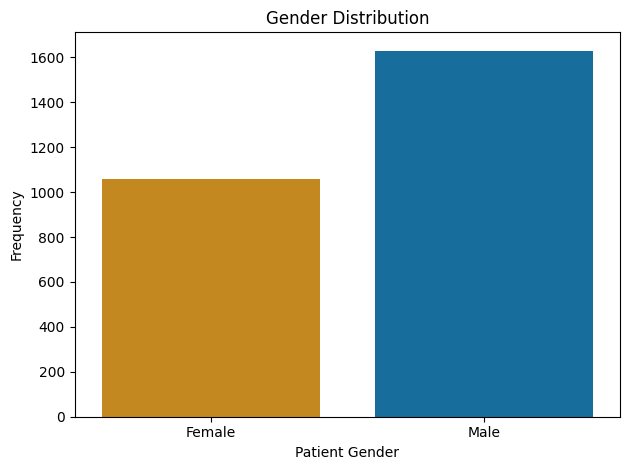

In [4]:
exploration_utils.plot_gender_distribution(gender_a)

## Age

In [5]:
age_a = df_combined_a['Patient Age']
np.unique(age_a)

array([ 1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
       87, 88, 89, 90, 91, 92], dtype=int32)

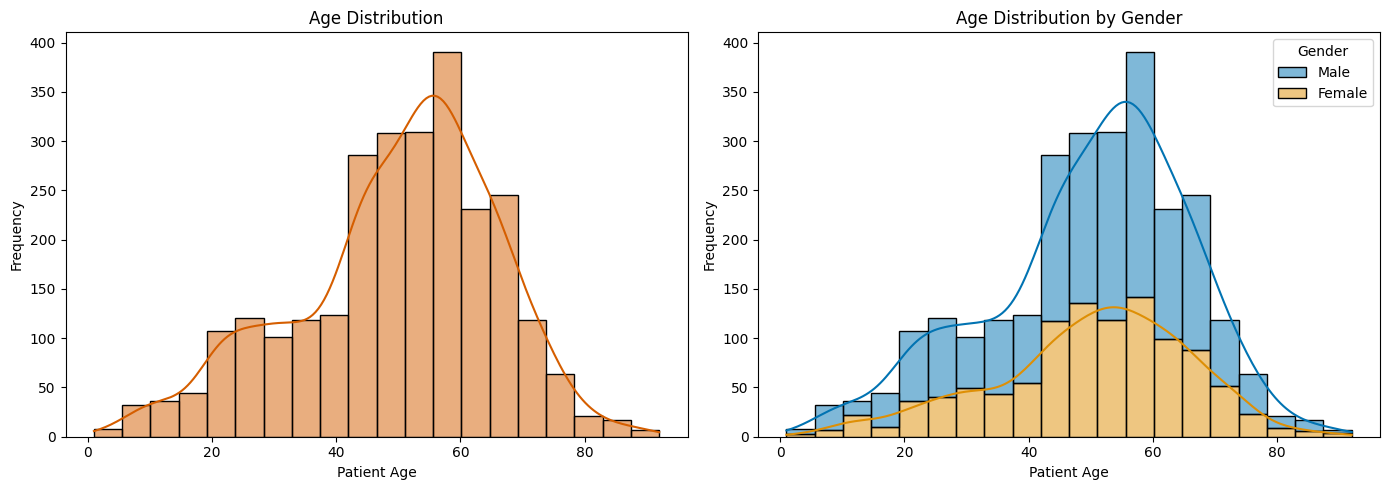

In [6]:
exploration_utils.plot_age_distribution_by_gender(age_a, gender_a)

## View Position

In [7]:
view_position_a = df_combined_a['View Position']
np.unique(view_position_a)

array(['AP', 'PA'], dtype=object)

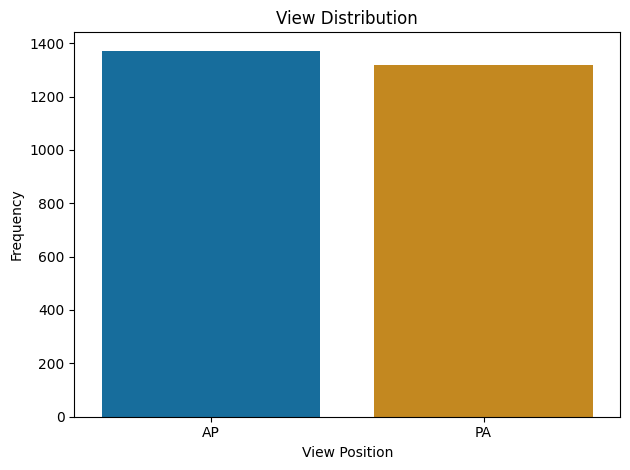

In [8]:
exploration_utils.plot_view_distribution(view_position_a)

## Pathology Concentration

In [9]:
label_a = df_combined_a['label']
np.unique(label_a.explode())

array(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration',
       'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia',
       'Pneumothorax'], dtype=object)

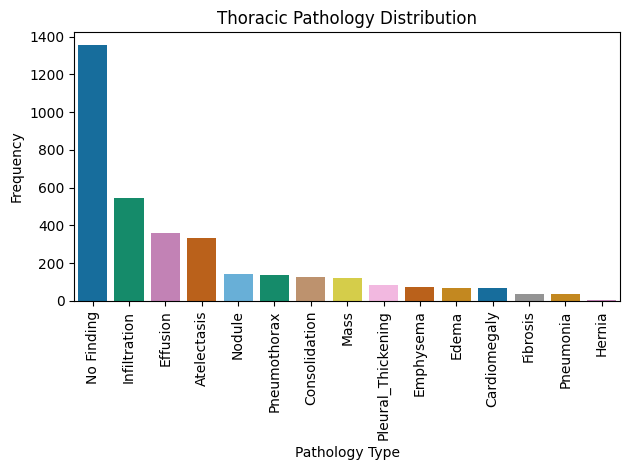

In [10]:
exploration_utils.plot_pathology_distribution(label_a)

## Patient Disjoint Splits

In [11]:
# Intersection of training set and eval set is the empty set; confirms patient-disjoint splits within hospitals -> No Data Leakage
overlap = set(df_train_a['Patient ID']).intersection(set(df_eval_a['Patient ID']))
overlap

set()

## All Distributions

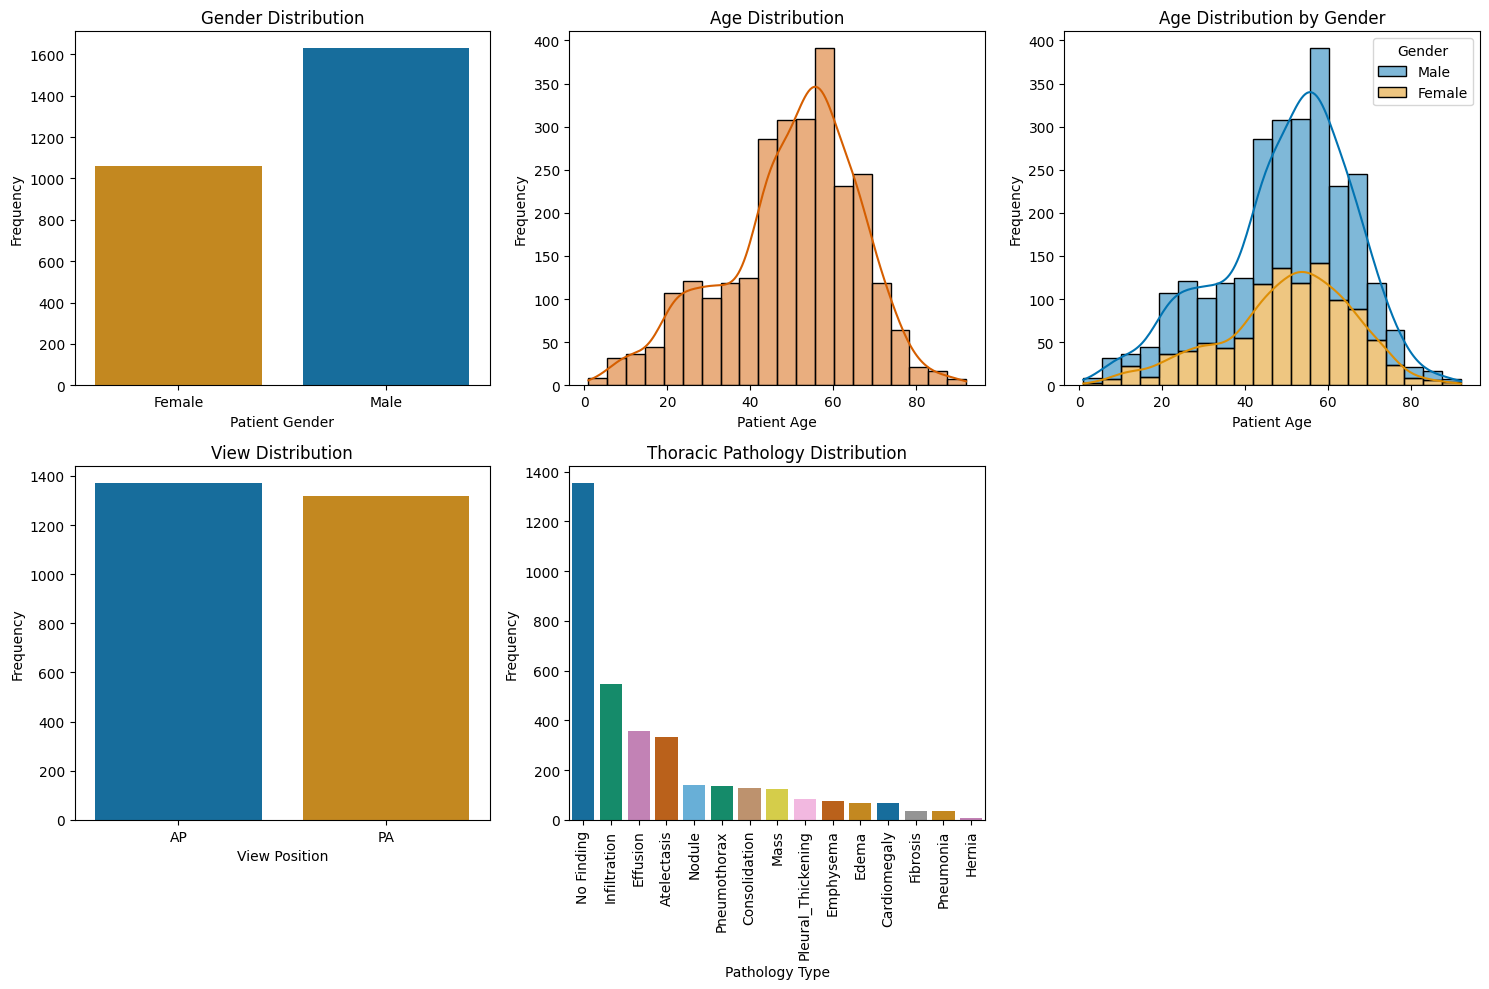

In [12]:
exploration_utils.plot_all_distributions(age_a, gender_a, view_position_a, label_a)

# Hospital B

### Data Distribution

| Category               | Distribution                                        |
|------------------------|-----------------------------------------------------|
| **Demographics**       | Mostly balanced, slightly more females; ages 25-65  |
| **Equipment**          | Predominantly PA views                              |
| **Common Pathologies** | Infiltration, Effusion, and Atelectasis             |

In [13]:
data_dir_b = '../../data/hospital_b/'

df_train_b, df_eval_b, df_combined_b = exploration_utils.get_hospital_dfs(data_dir_b, train_filenames, eval_filenames)
df_combined_b.columns

Index(['image', 'label', 'Patient Age', 'Patient Gender', 'View Position',
       'Patient ID'],
      dtype='object')

## All Distributions

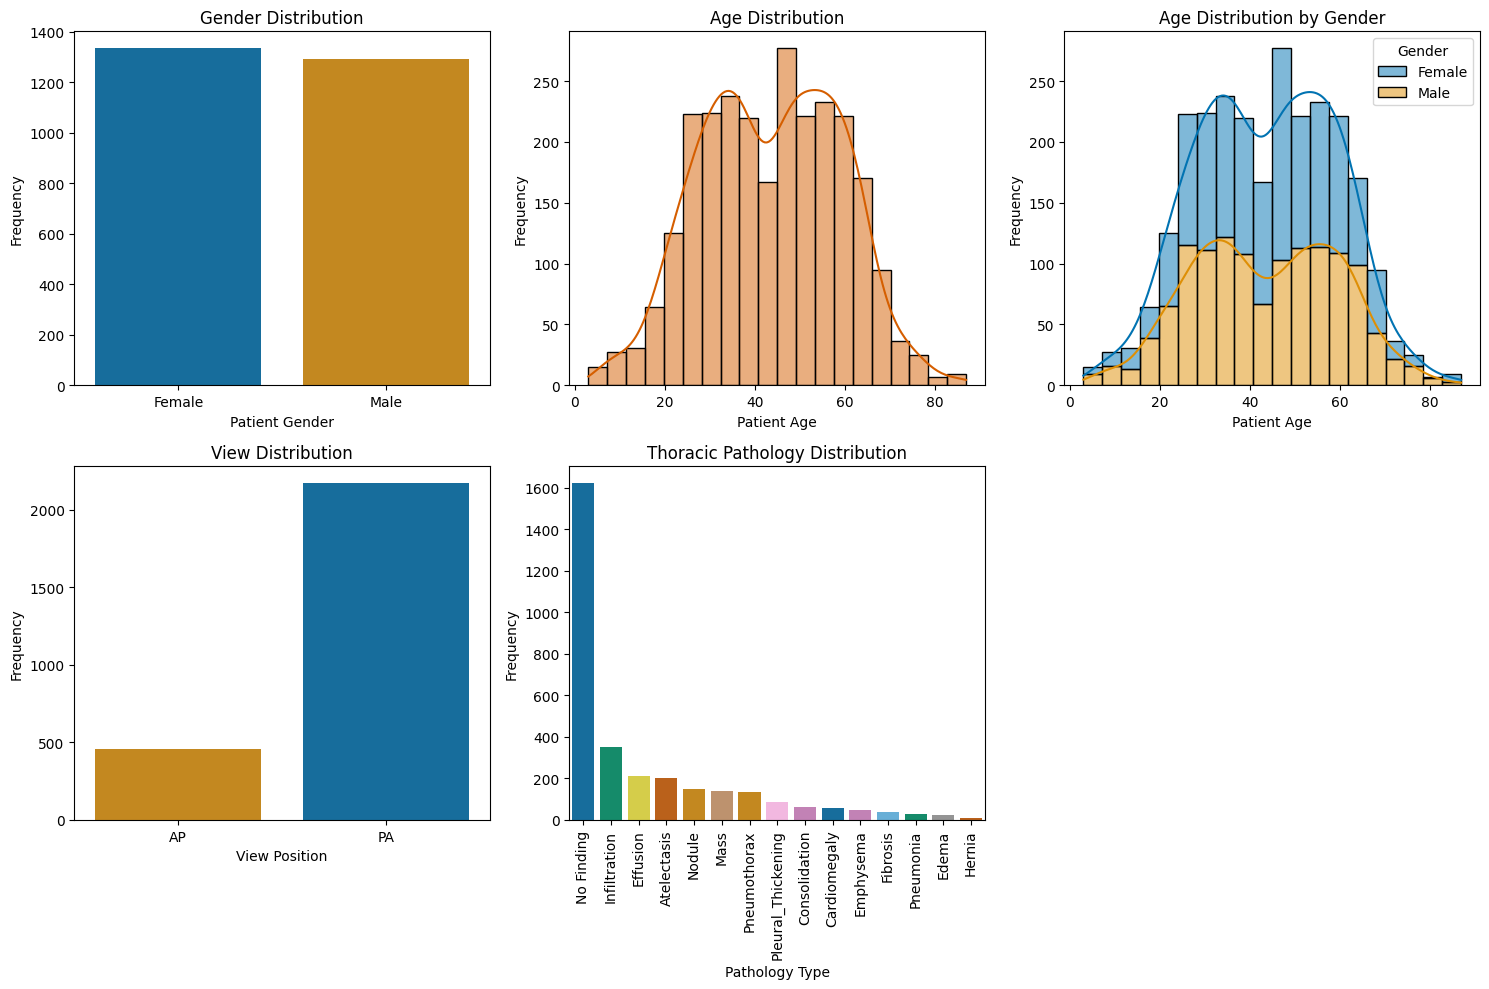

In [14]:
exploration_utils.plot_all_distributions(df_combined_b['Patient Age'], df_combined_b['Patient Gender'], 
                                         df_combined_b['View Position'], df_combined_b['label'])

## Patient Disjoint Splits

In [15]:
overlap = set(df_train_b['Patient ID']) & (set(df_eval_b['Patient ID']))
overlap

set()

# Hospital C

### Data Distribution

| Category               | Distribution                                        |
|------------------------|-----------------------------------------------------|
| **Demographics**       | Predominantly male; mixed ages                      |
| **Equipment**          | More PA views                                       |
| **Common Pathologies** | Infiltration, Effusion, and Atelectasis             |

In [16]:
data_dir_c = '../../data/hospital_c/'

df_train_c, df_eval_c, df_combined_c = exploration_utils.get_hospital_dfs(data_dir_c, train_filenames, eval_filenames)
df_combined_c.columns

Index(['image', 'label', 'Patient Age', 'Patient Gender', 'View Position',
       'Patient ID'],
      dtype='object')

## All Distributions

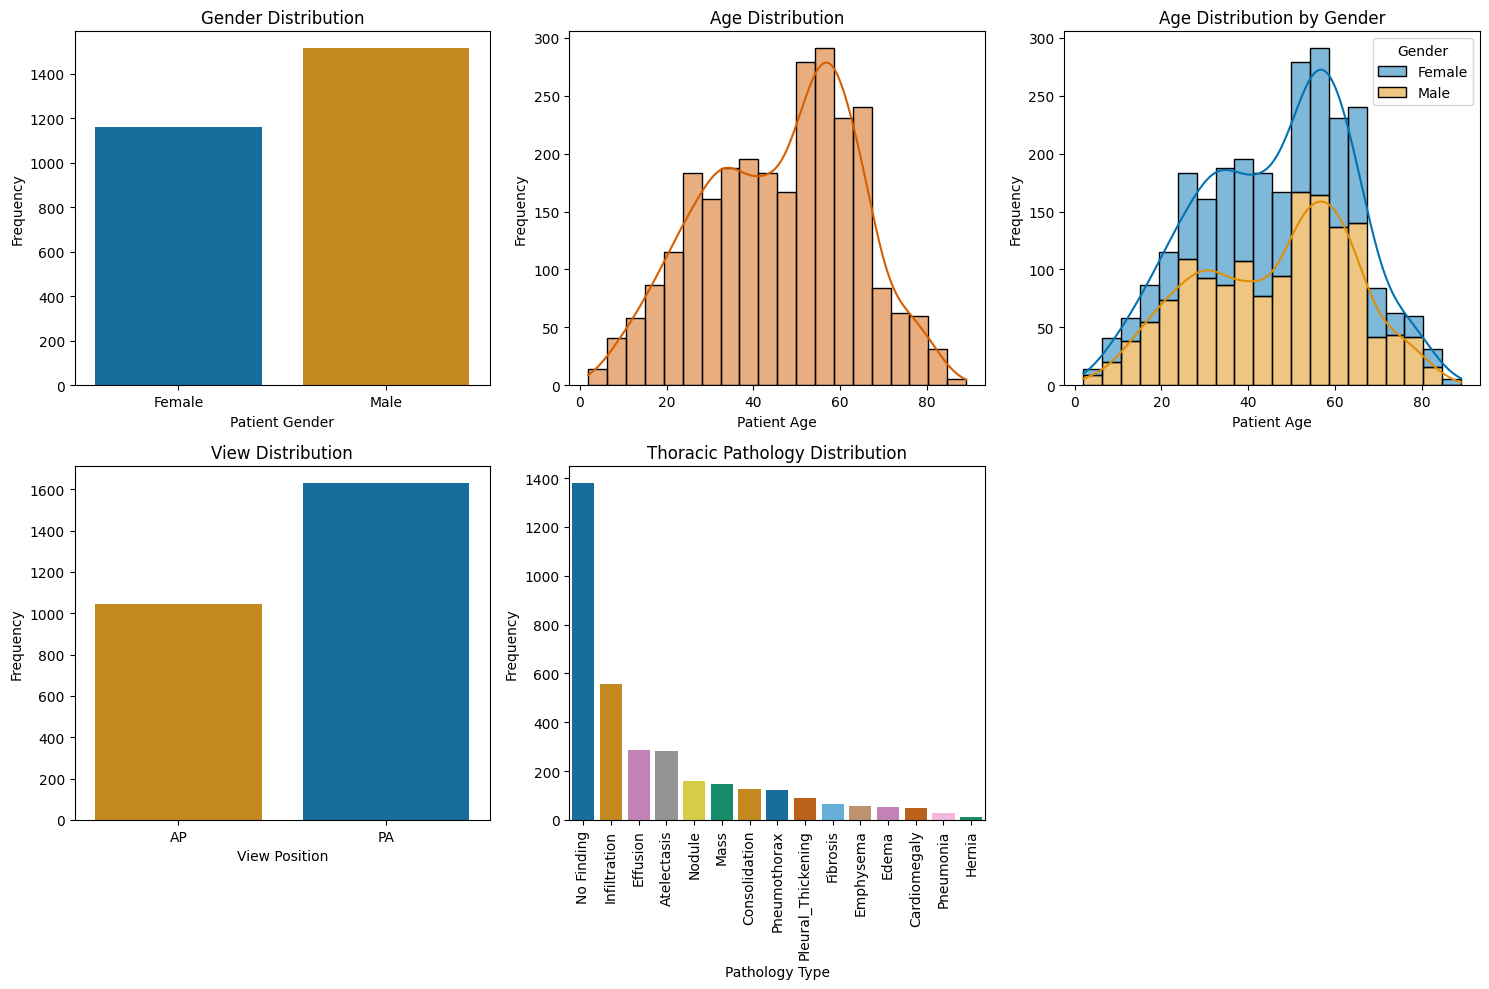

In [17]:
exploration_utils.plot_all_distributions(df_combined_c['Patient Age'], df_combined_c['Patient Gender'], 
                                         df_combined_c['View Position'], df_combined_c['label'])

## Patient Disjoint Splits

In [18]:
overlap = set(df_train_c['Patient ID']) & (set(df_eval_c['Patient ID']))
overlap

set()

### Hospital Disjoint Splits

In [19]:
ab_overlap = set(df_combined_a['Patient ID']) & set(df_combined_b['Patient ID'])
ac_overlap = set(df_combined_a['Patient ID']) & set(df_combined_c['Patient ID'])
bc_overlap = set(df_combined_b['Patient ID']) & set(df_combined_c['Patient ID'])
ab_overlap, ac_overlap, bc_overlap

(set(), set(), set())